Dataset Preview:
   CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0

Dataset Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Missing Values:
 CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64
Duplicate Rows: 0


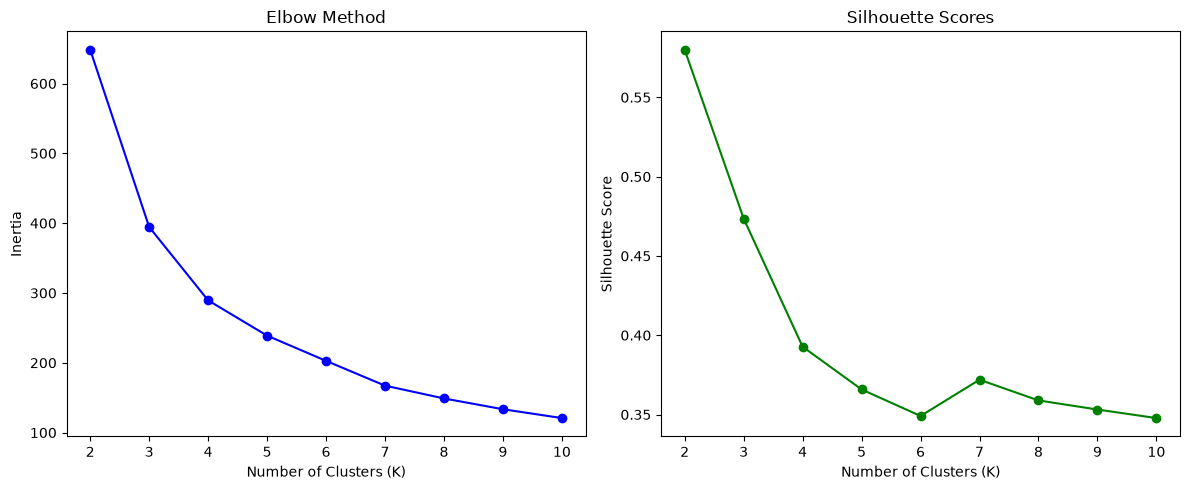

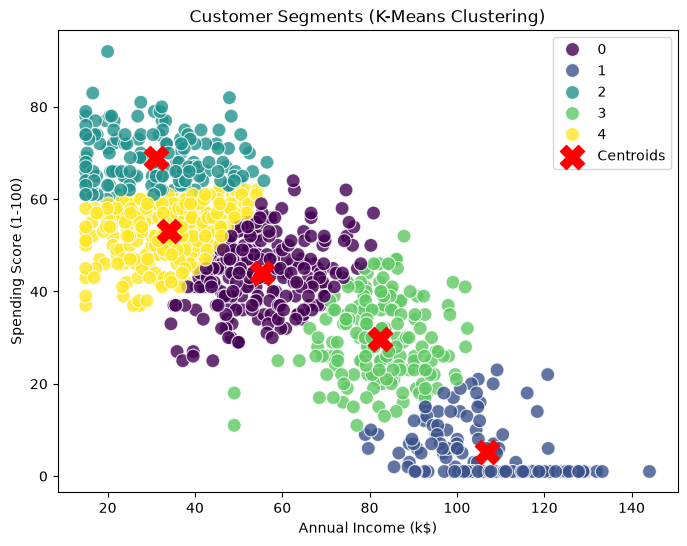


Cluster Characteristics Summary:
         Annual Income (k$)  Spending Score (1-100)  Num_Customers
Cluster                                                           
0                 55.338494               43.933054            239
1                106.905147                5.257353            136
2                 31.031788               68.854305            151
3                 82.477273               29.710227            176
4                 34.059396               53.124161            298


In [ ]:
import matplotlib.pyplot as plt    #Pragya Singhal, CU24220050, 43
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('store_customers.csv')

print('Dataset Preview:')    #Pragya Singhal, CU24220050, 43
print(df.head())
print('\nDataset Columns:')
print(df.columns)

# Step 3: Data Preprocessing  #Pragya Singhal, CU24220050, 43
print('\nMissing Values:\n', df.isnull().sum())
print('Duplicate Rows:', df.duplicated().sum())

income_col = (
    'Annual Income (k$)'
    if 'Annual Income (k$)' in df.columns
    else df.columns[1]
)
spending_col = (
    'Spending Score (1-100)'
    if 'Spending Score (1-100)' in df.columns
    else df.columns[2]
)
df[[income_col, spending_col]] = df[[income_col, spending_col]].fillna(
    df[[income_col, spending_col]].median()
)
X = df[[income_col, spending_col]]

# Step 4: Feature Scaling  #Pragya Singhal, CU24220050, 43
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)
  silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plotting the Elbow Curve and Silhouette Scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='g')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# Step 6: Apply K-Means Clustering with Optimal K (K=5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Step 7: Visualize Clusters and Centroids   #Pragya Singhal, CU24220050, 43
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=income_col,
    y=spending_col,
    hue='Cluster',
    data=df,
    palette='viridis',
    s=100,
    alpha=0.8,
)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids',
)
plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel(income_col)
plt.ylabel(spending_col)
plt.legend()
plt.show()

# Step 8 & 9: Analyze Characteristics   #Pragya Singhal, CU24220050, 43
cluster_summary = (
    df.groupby('Cluster')
    .agg({income_col: 'mean', spending_col: 'mean', df.columns[0]: 'count'})
    .rename(columns={df.columns[0]: 'Num_Customers'})
)

print('\nCluster Characteristics Summary:')
print(cluster_summary)